# Selection Algorithm Analysis

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
data=pd.read_csv('ga_selection_analysis.csv',index_col='Generation')

In [43]:
data.head()

,tournament|team_swap|global_perm|elitism=True,tournament|team_swap|random_swap|elitism=True,tournament|team_swap|between_teams|elitism=True,tournament|team_two_point|global_perm|elitism=True,tournament|team_two_point|random_swap|elitism=True,tournament|team_two_point|between_teams|elitism=True,fitness_proportionate|team_swap|global_perm|elitism=True,fitness_proportionate|team_swap|random_swap|elitism=True,fitness_proportionate|team_swap|between_teams|elitism=True,fitness_proportionate|team_two_point|global_perm|elitism=True,...,tournament|team_swap|between_teams|elitism=False,tournament|team_two_point|global_perm|elitism=False,tournament|team_two_point|random_swap|elitism=False,tournament|team_two_point|between_teams|elitism=False,fitness_proportionate|team_swap|global_perm|elitism=False,fitness_proportionate|team_swap|random_swap|elitism=False,fitness_proportionate|team_swap|between_teams|elitism=False,fitness_proportionate|team_two_point|global_perm|elitism=False,fitness_proportionate|team_two_point|random_swap|elitism=False,fitness_proportionate|team_two_point|between_teams|elitism=False
Generation,,,,,,,,,,,,,,,,,,,,,
0,0.780428,0.784018,0.802709,0.802709,0.801649,0.802709,0.740807,0.751463,0.762442,0.747379,...,0.801649,0.811612,0.798526,0.769475,0.778724,0.738246,0.743367,0.720689,0.766249,0.748072
1,0.829201,0.834800,0.852073,0.839174,0.839174,0.837675,0.761708,0.792480,0.800589,0.786809,...,0.840674,0.860938,0.837675,0.829201,0.780428,0.769475,0.772701,0.781286,0.751463,0.747531
2,0.851179,0.860938,0.875027,0.860938,0.859171,0.860938,0.791509,0.813953,0.802709,0.811612,...,0.872839,0.875027,0.872839,0.852073,0.782182,0.757900,0.784018,0.792894,0.754315,0.767840
3,0.872839,0.872839,0.897436,0.872839,0.872839,0.864684,0.820215,0.837675,0.804891,0.831926,...,0.875027,0.887326,0.875027,0.864684,0.790539,0.798526,0.782182,0.761708,0.771067,0.768694
4,0.881958,0.877215,0.897436,0.875027,0.875027,0.864684,0.839174,0.839174,0.831926,0.842792,...,0.877215,0.887326,0.877215,0.864684,0.790539,0.795564,0.783079,0.790539,0.769475,0.764688


In [44]:
data.tail()

,tournament|team_swap|global_perm|elitism=True,tournament|team_swap|random_swap|elitism=True,tournament|team_swap|between_teams|elitism=True,tournament|team_two_point|global_perm|elitism=True,tournament|team_two_point|random_swap|elitism=True,tournament|team_two_point|between_teams|elitism=True,fitness_proportionate|team_swap|global_perm|elitism=True,fitness_proportionate|team_swap|random_swap|elitism=True,fitness_proportionate|team_swap|between_teams|elitism=True,fitness_proportionate|team_two_point|global_perm|elitism=True,...,tournament|team_swap|between_teams|elitism=False,tournament|team_two_point|global_perm|elitism=False,tournament|team_two_point|random_swap|elitism=False,tournament|team_two_point|between_teams|elitism=False,fitness_proportionate|team_swap|global_perm|elitism=False,fitness_proportionate|team_swap|random_swap|elitism=False,fitness_proportionate|team_swap|between_teams|elitism=False,fitness_proportionate|team_two_point|global_perm|elitism=False,fitness_proportionate|team_two_point|random_swap|elitism=False,fitness_proportionate|team_two_point|between_teams|elitism=False
Generation,,,,,,,,,,,,,,,,,,,,,
95,0.886701,0.887326,0.90342,0.875027,0.875027,0.864684,0.886701,0.897436,0.897436,0.872839,...,0.886701,0.900428,0.887326,0.864684,0.833575,0.802709,0.801649,0.802246,0.802709,0.771067
96,0.886701,0.887326,0.90342,0.875027,0.875027,0.864684,0.886701,0.897436,0.897436,0.872839,...,0.886701,0.900428,0.887326,0.864684,0.833575,0.802709,0.801649,0.802246,0.802709,0.771067
97,0.886701,0.887326,0.90342,0.875027,0.875027,0.864684,0.886701,0.897436,0.897436,0.872839,...,0.886701,0.900428,0.887326,0.864684,0.833575,0.802709,0.801649,0.802246,0.802709,0.771067
98,0.886701,0.887326,0.90342,0.875027,0.875027,0.864684,0.886701,0.897436,0.897436,0.872839,...,0.886701,0.900428,0.887326,0.864684,0.833575,0.802709,0.801649,0.802246,0.802709,0.771067
99,0.886701,0.887326,0.90342,0.875027,0.875027,0.864684,0.886701,0.897436,0.897436,0.872839,...,0.886701,0.900428,0.887326,0.864684,0.833575,0.802709,0.801649,0.802246,0.802709,0.771067


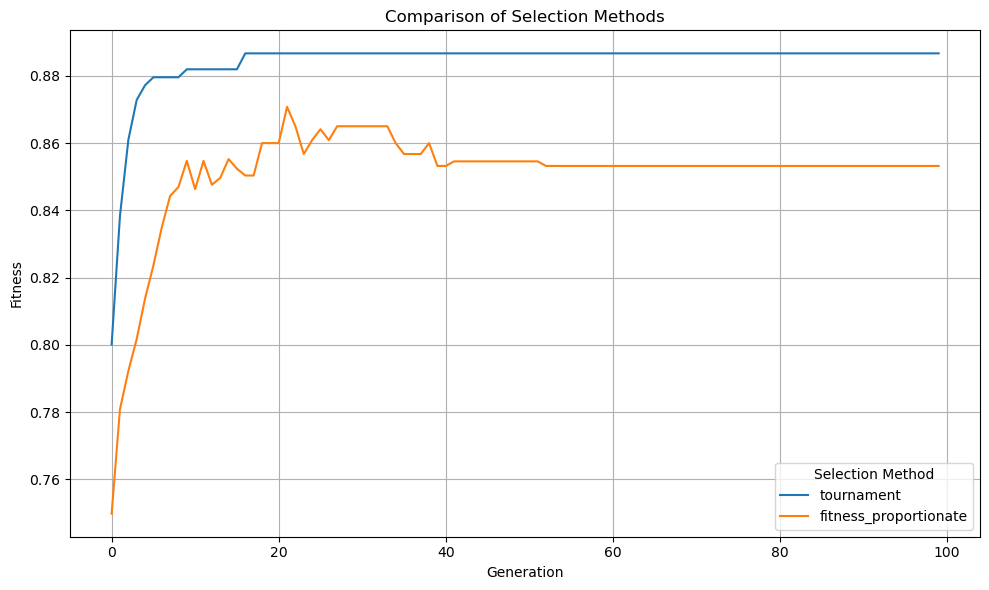

In [47]:
selection_results = {}

# iterate through each column in the dataset
for col in data.columns:
    selection_method = col.split("|")[0]  # extract "tournament" or "fitness_proportionate"
    #initialize list for each method
    if selection_method not in selection_results:
        selection_results[selection_method] = []
    
    # add column to the appropriate selection method group
    selection_results[selection_method].append(data[col])

# compute the median fitness per generation across all configurations of the same selection method
selection_avg_df = pd.DataFrame({
    method: pd.concat(columns, axis=1).median(axis=1)
    for method, columns in selection_results.items()
})

# plot
plt.figure(figsize=(10, 6))

for method in selection_avg_df.columns:
    plt.plot(selection_avg_df.index, selection_avg_df[method], label=method)

plt.title("Comparison of Selection Methods")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend(title="Selection Method")
plt.grid(True)
plt.tight_layout()
plt.show()

Moving forward we will use the tournament method to evaluate the best combination of crossover and mutation